In [1]:
import pandas as pd
df = pd.read_parquet("../cleaned_data.parquet").reset_index()

In [73]:
df.sample(20)

,index,key_1,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,Street Name,Address Type,City,Status,Community Board,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Open Data Channel Type,Park Borough,Latitude,Longitude,resolution_time_days,hour_of_day,day_of_week,month,is_weekend,open_requests_same_day_zip,resolution_class
1853461,1985762,2025-03-01,64228545,2025-03-01 21:53:32,2025-03-04 14:35:14,DPR,DEPARTMENT OF PARKS AND RECREATION,DAMAGED TREE,ENTIRE TREE HAS FALLEN DOWN,STREET,11365,187-20 PECK AVENUE,PECK AVENUE,ADDRESS,FRESH MEADOWS,CLOSED,11 QUEENS,QUEENS,1042647,210662,UNKNOWN,QUEENS,40.744702,-73.789253,2.695625,21,5,3,1,47,1-3
2050472,2189463,2025-02-07,64009623,2025-02-07 13:46:24,2025-02-09 08:47:05,HPD,DEPARTMENT OF HOUSING PRESERVATION AND DEVELOPMENT,ELECTRIC,OUTLET/SWITCH,RESIDENTIAL BUILDING,10452,1522 UNIVERSITY AVENUE,UNIVERSITY AVENUE,ADDRESS,BRONX,CLOSED,05 BRONX,BRONX,1005789,247374,PHONE,BRONX,40.845633,-73.922151,1.792141,13,4,2,0,104,1-3
14902,24168,2025-09-30,66327457,2025-09-30 14:37:17,2025-09-30 15:04:17,NYPD,NEW YORK CITY POLICE DEPARTMENT,NON-EMERGENCY POLICE MATTER,OTHER (COMPLAINT DETAILS),STREET/SIDEWALK,11208,69 WELDON STREET,WELDON STREET,ADDRESS,BROOKLYN,CLOSED,05 BROOKLYN,BROOKLYN,1019654,187067,PHONE,BROOKLYN,40.680062,-73.872355,0.018750,14,1,9,0,72,0
579885,646470,2025-07-25,65660775,2025-07-25 18:06:11,2025-07-28 08:19:01,DPR,DEPARTMENT OF PARKS AND RECREATION,WOOD PILE REMAINING,REMOVE DEBRIS,STREET,10305,75 BRIARCLIFF ROAD,BRIARCLIFF ROAD,ADDRESS,STATEN ISLAND,CLOSED,02 STATEN ISLAND,STATEN ISLAND,962975,157274,PHONE,STATEN ISLAND,40.598332,-74.07661,2.592245,18,4,7,0,96,1-3
1436368,1550389,2025-04-19,64700319,2025-04-19 06:43:31,2025-04-19 07:59:23,NYPD,NEW YORK CITY POLICE DEPARTMENT,ILLEGAL PARKING,POSTED PARKING SIGN VIOLATION,STREET/SIDEWALK,11232,44 STREET,44 STREET,INTERSECTION,BROOKLYN,CLOSED,07 BROOKLYN,BROOKLYN,983580,174561,MOBILE,BROOKLYN,40.645806,-74.002414,0.052685,6,5,4,1,25,0
1093351,1189805,2025-05-27,65077672,2025-05-27 08:16:15,2025-07-16 00:00:00,DOB,DEPARTMENT OF BUILDINGS,PLUMBING,PLUMBING WORK - ILLEGAL/NO PERMIT/STANDPIPE/SPRINKLER,UNKNOWN,10032,270 FORT WASHINGTON AVENUE,FORT WASHINGTON AVENUE,ADDRESS,NEW YORK,CLOSED,12 MANHATTAN,MANHATTAN,1000575,246859,UNKNOWN,MANHATTAN,40.844231,-73.940997,49.655382,8,1,5,0,142,31-60
2275076,2419138,2025-01-14,63764879,2025-01-14 19:41:16,2025-01-14 20:54:28,NYPD,NEW YORK CITY POLICE DEPARTMENT,ILLEGAL PARKING,UNAUTHORIZED BUS LAYOVER,STREET/SIDEWALK,11205,149 FRANKLIN AVENUE,FRANKLIN AVENUE,ADDRESS,BROOKLYN,CLOSED,03 BROOKLYN,BROOKLYN,995914,192169,MOBILE,BROOKLYN,40.694129,-73.957938,0.050833,19,1,1,0,81,0
1117348,1214715,2025-05-24,65049595,2025-05-24 13:07:04,2025-05-24 13:39:05,NYPD,NEW YORK CITY POLICE DEPARTMENT,ILLEGAL PARKING,BLOCKED SIDEWALK,STREET/SIDEWALK,11205,298 CLASSON AVENUE,CLASSON AVENUE,ADDRESS,BROOKLYN,CLOSED,02 BROOKLYN,BROOKLYN,995261,190775,ONLINE,BROOKLYN,40.690303,-73.960295,0.022234,13,5,5,1,65,0
123808,154233,2025-09-17,66183013,2025-09-17 20:56:59,2025-09-17 22:49:13,NYPD,NEW YORK CITY POLICE DEPARTMENT,NOISE - VEHICLE,CAR/TRUCK MUSIC,STREET/SIDEWALK,10034,175 SHERMAN AVENUE,SHERMAN AVENUE,ADDRESS,NEW YORK,CLOSED,12 MANHATTAN,MANHATTAN,1005689,254381,ONLINE,MANHATTAN,40.864866,-73.92249,0.077940,20,2,9,0,39,0
2040729,2179449,2025-02-08,64026708,2025-02-08 18:12:26,2025-02-10 11:53:41,HPD,DEPARTMENT OF HOUSING PRESERVATION AND DEVELOPMENT,HEAT/HOT WATER,ENTIRE BUILDING,RESIDENTIAL BUILDING,10468,2355 GRAND CONCOURSE,GRAND CONCOURSE,ADDRESS,BRONX,CLOSED,05 BRONX,BRONX,1012170,252230,ONLINE,BRONX,40.858944,-73.899067,1.736979,18,5,2,1,105,1-3


In [2]:
# Derived temporal features
df['resolution_time_days'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 86400
df['hour_of_day'] = df['Created Date'].dt.hour
df['day_of_week'] = df['Created Date'].dt.dayofweek
df['month'] = df['Created Date'].dt.month
df['is_weekend'] = df['day_of_week'] >= 5
df['is_weekend'] = df['is_weekend'].astype(int)

In [3]:

# More complex feature. Add total open tickets in lat 24 hours to model the load
df = df.sort_values(['Incident Zip', 'Created Date'])

temp_df = df.set_index('Created Date')

# 3. Calculate
rolling_result = temp_df.groupby('Incident Zip')['Unique Key'] \
                        .rolling('24h', closed='left') \
                        .count()

df['open_requests_past_24h'] = rolling_result.values

df['open_requests_past_24h'] = df['open_requests_past_24h'].fillna(0)

count    2.449109e+06
mean     5.338575e+00
std      1.875348e+01
min      0.000000e+00
25%      3.706019e-02
50%      1.809838e-01
75%      1.951273e+00
max      2.710992e+02
Name: resolution_time_days, dtype: float64
> 7 days: 301209
> 14 days: 200457
> 30 days: 119898
> 45 days: 82739
> 60 days: 62821
> 90 days: 29587
> 120 days: 17220


<Axes: title={'center': 'Resolution Time Distribution (0–200 days)'}, ylabel='Frequency'>

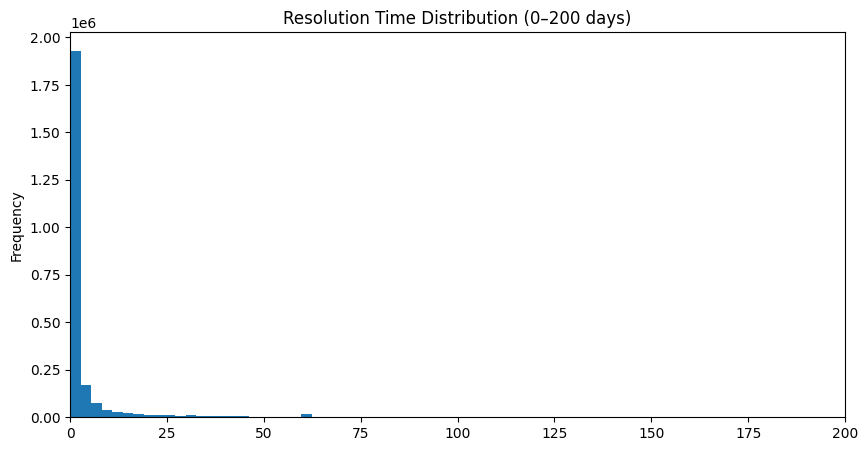

In [4]:
print(df['resolution_time_days'].describe())
for t in [7, 14, 30, 45, 60, 90, 120]:
    count = (df['resolution_time_days'] > t).sum()
    print(f"> {t} days:", count)
df['resolution_time_days'].plot(
    kind='hist',
    bins=100,
    xlim=(0, 200),     # adjust if your max is below 200
    figsize=(10,5),
    title='Resolution Time Distribution (0–200 days)'
)

<Axes: title={'center': 'Resolution Time Distribution (0–60 days)'}, ylabel='Frequency'>

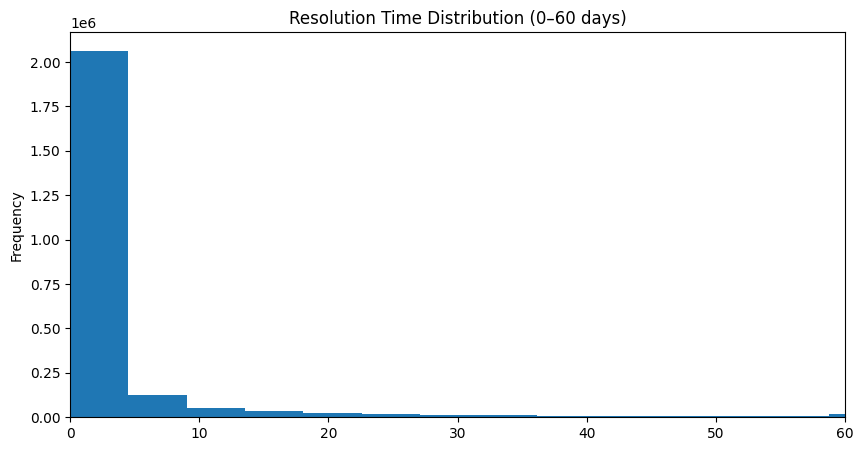

In [5]:

df['resolution_time_days'].plot(
    kind='hist',
    bins=60,
    xlim=(0, 60),      # only the meaningful range
    figsize=(10,5),
    title='Resolution Time Distribution (0–60 days)'
)


<Axes: title={'center': 'Resolution Time Distribution (Log Scale)'}, ylabel='Frequency'>

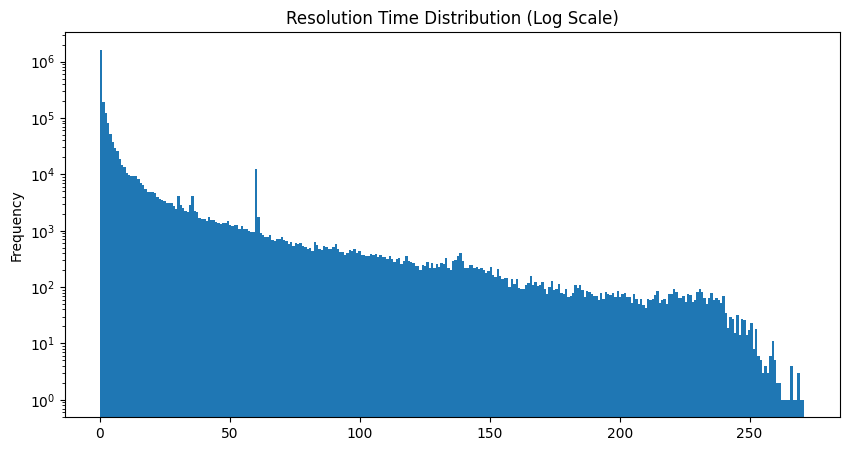

In [6]:
import numpy as np
df['resolution_time_days'].plot(
    kind='hist',
    bins=300,
    log=True,          # <— log scale
    figsize=(10,5),
    title='Resolution Time Distribution (Log Scale)'
)

In [7]:
df = df[df['resolution_time_days'] <= 60]

In [8]:

# To Determine which buckets should we assign
df.groupby(df['resolution_time_days'].astype(int)).size()


resolution_time_days
0     1656723
1      189408
2      117819
3       72982
4       46394
       ...   
56       1179
57       1081
58       1097
59       1014
60          1
Length: 61, dtype: int64

In [9]:
def get_buckets(days):
    if days < 1:
        return '0'
    elif days < 4:
        return '1-3'
    elif days < 8:
        return '4-7'
    elif days < 15:
        return '8-14'
    elif days < 31:
        return '15-30'
    else:
        return '31-60'
    
df['resolution_class'] = df['resolution_time_days'].astype(int).apply(get_buckets)

In [10]:
df.to_parquet("../classify_data.parquet")

In [70]:
# show all columns in DataFrame output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# optionally, avoid truncating text values
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 2000)


In [ ]:
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')
pd.reset_option('display.max_colwidth')
pd.reset_option('display.width')
